In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib  # for saving class weights as .pkl

from sklearn.utils import class_weight

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

# Input files
X_TRAIN_PATH = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/01 - Data Cleaning and Preprocessing/X_train_final_v2.csv"
Y_TRAIN_PATH = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/01 - Data Cleaning and Preprocessing/y_train.csv"


#### Step 1: Load Training Data

In [3]:

X_train = pd.read_csv(X_TRAIN_PATH)
y_train_df = pd.read_csv(Y_TRAIN_PATH)

# Inspect columns in y_train to pick the right target column
print("y_train columns:", y_train_df.columns.tolist())

# Change 'target' to your actual target column name
TARGET_COL = y_train_df.columns[0]
y_train = y_train_df[TARGET_COL]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

# Quick sanity check: number of samples must match
assert len(X_train) == len(y_train), "X and y have different number of rows!"

# Look at class distribution
print("\nOriginal class distribution:")
print(y_train.value_counts(normalize=False))
print("\nOriginal class distribution (proportions):")
print(y_train.value_counts(normalize=True))


y_train columns: ['BRIDGE_CONDITION']
X_train shape: (1236125, 102)
y_train shape: (1236125,)

Original class distribution:
BRIDGE_CONDITION
F    606141
G    545841
P     84143
Name: count, dtype: int64

Original class distribution (proportions):
BRIDGE_CONDITION
F    0.490356
G    0.441574
P    0.068070
Name: proportion, dtype: float64


#### Step 2: Compute Class Weights (No Resampling)

In [4]:
from sklearn.utils import class_weight
import numpy as np
import joblib

# Inspect imbalance
print("Class counts:")
print(y_train.value_counts())

print("\nClass proportions:")
print(y_train.value_counts(normalize=True))

# Compute class weights
classes = np.unique(y_train)

weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print("\nComputed class weights:")
for cls, w in class_weights.items():
    print(f"Class {cls}: {w:.4f}")

# Save to pickle
CLASS_WEIGHTS_PATH = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/03 - Class Imbalance/class_weights.pkl"
joblib.dump(class_weights, CLASS_WEIGHTS_PATH)

print(f"\nSaved class weights to: {CLASS_WEIGHTS_PATH}")


Class counts:
BRIDGE_CONDITION
F    606141
G    545841
P     84143
Name: count, dtype: int64

Class proportions:
BRIDGE_CONDITION
F    0.490356
G    0.441574
P    0.068070
Name: proportion, dtype: float64

Computed class weights:
Class F: 0.6798
Class G: 0.7549
Class P: 4.8969

Saved class weights to: /content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/03 - Class Imbalance/class_weights.pkl


The distribution of the target variable shows that most bridge components fall into conditions F (49%) and G (44%), while the P class, representing poor or deficient conditions, accounts for only 6.8% of the data. This indicates a moderate class imbalance where the minority class (P) is significantly underrepresented compared to the others. Because machine-learning models tend to prioritize the majority classes during training, this imbalance could cause the model to overlook or misclassify the most critical cases: bridges in poor condition. The computed class weights reflect this discrepancy: both F and G receive weights under 1, while class P receives a much higher weight of 4.8969, meaning errors on P samples will be penalized almost five times more during model training.

### Step 3: SMOTE Oversampling

SMOTE will directly balance the training data by creating synthetic samples for the minority class.

Why SMOTE?
*   It creates new synthetic P samples by interpolating between actual P points.
*   This avoids simple duplication (which can cause overfitting).
*   It balances the dataset numerically so models have enough examples from each class.

After SMOTE, all classes will have equal counts.



In [ ]:
# from imblearn.over_sampling import SMOTE
# import pandas as pd

# # SMOTE Oversampling

# print("Applying SMOTE...")

# smote = SMOTE(random_state=42)
# X_smote, y_smote = smote.fit_resample(X_train, y_train)

# print("\nAfter SMOTE:")
# print("X_smote shape:", X_smote.shape)
# print("y_smote shape:", y_smote.shape)

# print("\nSMOTE class distribution:")
# print(pd.Series(y_smote).value_counts())

# print("\nSMOTE class proportions:")
# print(pd.Series(y_smote).value_counts(normalize=True))

# # Save results
# X_smote.to_csv("X_train_smote.csv", index=False)
# pd.DataFrame({TARGET_COL: y_smote}).to_csv("y_train_smote.csv", index=False)

# print("\nSaved SMOTE outputs to:")
# print("  X_train_smote.csv")
# print("  y_train_smote.csv")


Applying SMOTE...


Why Partial SMOTE Instead of Full SMOTE?

The original SMOTE plan would have oversampled the minority class (P) from about 84,000 samples to match the largest class (over 600,000 samples). However, applying full SMOTE on a dataset of this size (over 1.2 million rows and 120 features) is extremely computationally expensive and will take a very long time to run. More importantly, generating such a large number of synthetic samples can introduce noise and reduce the overall quality of the training data.

To avoid these issues while still addressing the class imbalance, I used partial SMOTE, oversampling class P to a more reasonable level (200,000 samples). This approach balances the dataset enough to help the model learn minority-class patterns, keeps runtime manageable, and avoids overwhelming the training process with synthetic data. It offers the benefits of SMOTE without the computational cost or risk of oversampling too aggressively.

In [5]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# Partial SMOTE Oversampling
print("Applying Partial SMOTE...")

# Oversample P to 200,000 (instead of 606,000)
smote = SMOTE(
    sampling_strategy={'P': 200000},
    random_state=42
)

X_smote, y_smote = smote.fit_resample(X_train, y_train)

print("\nAfter Partial SMOTE:")
print("X_smote shape:", X_smote.shape)
print("y_smote shape:", y_smote.shape)

print("\nPartial SMOTE class distribution:")
print(pd.Series(y_smote).value_counts())

print("\nPartial SMOTE class proportions:")
print(pd.Series(y_smote).value_counts(normalize=True))

X_SMOTE_PATH = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/03 - Class Imbalance/X_train_smote.csv"
Y_SMOTE_PATH = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/03 - Class Imbalance/y_train_smote.csv"

# Save the results
X_smote.to_csv(X_SMOTE_PATH, index=False)
pd.DataFrame({TARGET_COL: y_smote}).to_csv(Y_SMOTE_PATH, index=False)

print("\nSaved Partial SMOTE outputs successfully.")


Applying Partial SMOTE...

After Partial SMOTE:
X_smote shape: (1351982, 102)
y_smote shape: (1351982,)

Partial SMOTE class distribution:
BRIDGE_CONDITION
F    606141
G    545841
P    200000
Name: count, dtype: int64

Partial SMOTE class proportions:
BRIDGE_CONDITION
F    0.448335
G    0.403734
P    0.147931
Name: proportion, dtype: float64

Saved Partial SMOTE outputs successfully.


#### Step 5: SMOTE + Tomek

This method combines two ideas in one pipeline:

###### SMOTE (oversampling)

*   Creates synthetic samples for the minority class P, just like in Step 3.
*   We’ll again use partial oversampling (P → 200,000) to keep things efficient and avoid flooding the data with synthetic points.


###### Tomek Links (undersampling / cleaning)

A Tomek link is a pair of samples from different classes that are each other’s nearest neighbors.
These pairs usually sit in overlapping or noisy boundary regions.

By removing the majority-class side of those pairs, we:

*   clean up the decision boundary
*   reduce overlap between classes
*   make the minority class region more distinct

So SMOTE + Tomek gives you a dataset that is partially oversampled and then boundary-cleaned, often smoother and less noisy than plain SMOTE.

In [6]:
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd

# Undersampling of SMOTE Output
print("Applying RandomUnderSampler to SMOTE dataset...")

# UnderSample majority classes from the SMOTE dataset
rus = RandomUnderSampler(sampling_strategy="auto", random_state=42)
X_combined, y_combined = rus.fit_resample(X_smote, y_smote)

print("\nAfter SMOTE + Undersampling:")
print("X_combined shape:", X_combined.shape)
print("y_combined shape:", y_combined.shape)

print("\nClass distribution:")
print(pd.Series(y_combined).value_counts())

print("\nClass proportions:")
print(pd.Series(y_combined).value_counts(normalize=True))

# Save results
X_combined.to_csv("X_train_combined.csv", index=False)
pd.DataFrame({TARGET_COL: y_combined}).to_csv("y_train_combined.csv", index=False)

print("\nSaved combined balanced dataset to:")
print("  X_train_combined.csv")
print("  y_train_combined.csv")


Applying RandomUnderSampler to SMOTE dataset...

After SMOTE + Undersampling:
X_combined shape: (600000, 102)
y_combined shape: (600000,)

Class distribution:
BRIDGE_CONDITION
F    200000
G    200000
P    200000
Name: count, dtype: int64

Class proportions:
BRIDGE_CONDITION
F    0.333333
G    0.333333
P    0.333333
Name: proportion, dtype: float64

Saved combined balanced dataset to:
  X_train_combined.csv
  y_train_combined.csv


#### Step 5 — Distribution comparison plot (Original vs SMOTE vs SMOTE→Undersampled)

We compare the class distributions across the three datasets (original, SMOTE-only, and SMOTE→RandomUnderSampler) to visualize how the imbalance has changed and to verify that resampling behaved as intended. The plot shows counts for each BRIDGE_CONDITION class side-by-side so you can quickly see whether P (the minority) has been sufficiently boosted and how the majority classes were affected.

Using in-memory X_train / y_train
Using in-memory SMOTE outputs
Using in-memory combined outputs


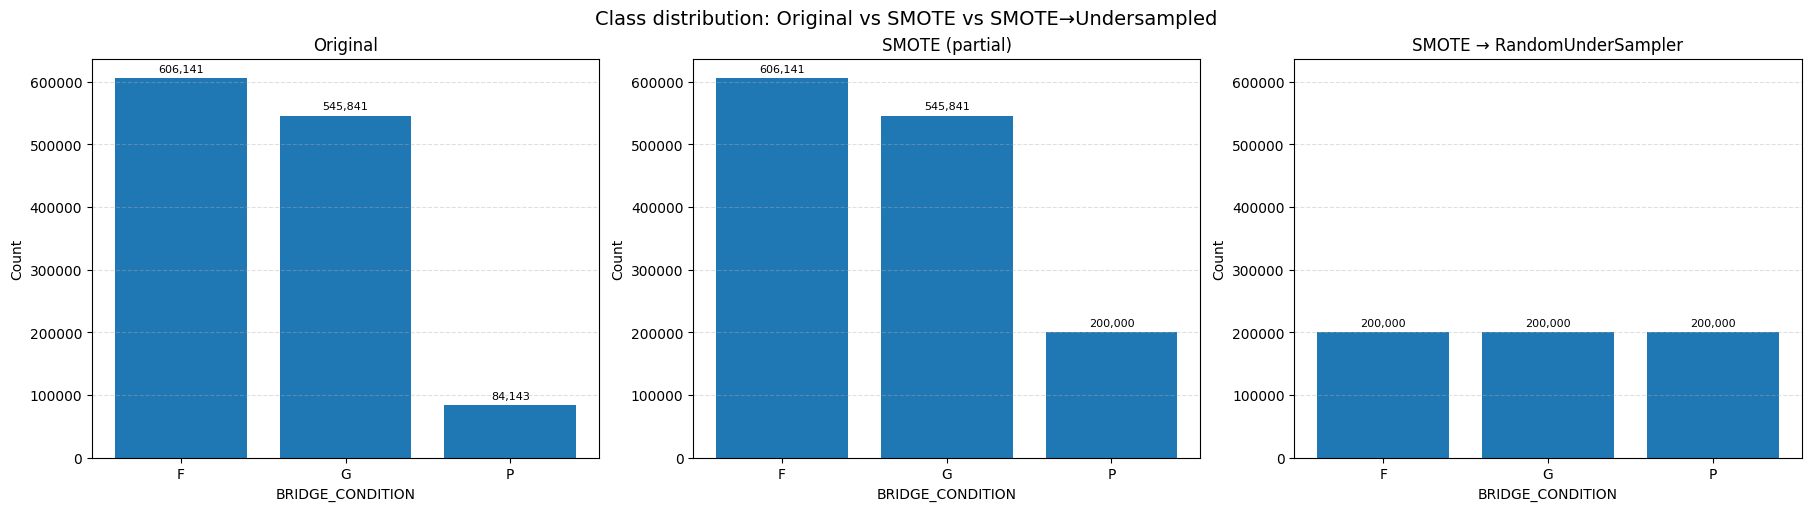


Saved distribution comparison plot to: /content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/03 - Class Imbalance/balance_comparison.png


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Paths (adjust if you used different names)
ORIG_X_PATH = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/01 - Data Cleaning and Preprocessing/X_train_final_v2.csv"
ORIG_Y_PATH = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/01 - Data Cleaning and Preprocessing/y_train.csv"
X_SMOTE_PATH = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/03 - Class Imbalance/X_train_smote.csv"
Y_SMOTE_PATH = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/03 - Class Imbalance/y_train_smote.csv"
X_COMB_PATH = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/03 - Class Imbalance/X_train_combined.csv"
Y_COMB_PATH = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/03 - Class Imbalance/y_train_combined.csv"
BALANCE_PLOT_PATH = "/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/03 - Class Imbalance/balance_comparison.png"

# Attempt to use in-memory variables if available, otherwise load from disk
try:
    X_train  # reference-only to check existence
    y_train
    print("Using in-memory X_train / y_train")
except NameError:
    print("Loading original X and y from disk...")
    X_train = pd.read_csv(ORIG_X_PATH)
    y_train_df = pd.read_csv(ORIG_Y_PATH)
    # if y file is a single-column DF, extract that column:
    if y_train_df.shape[1] == 1:
        y_train = y_train_df.iloc[:, 0]
    else:
        # try to find BRIDGE_CONDITION column
        if "BRIDGE_CONDITION" in y_train_df.columns:
            y_train = y_train_df["BRIDGE_CONDITION"]
        else:
            # fallback: first column
            y_train = y_train_df.iloc[:, 0]

# Load SMOTE output (if not in memory)
try:
    X_smote
    y_smote
    print("Using in-memory SMOTE outputs")
except NameError:
    if os.path.exists(Y_SMOTE_PATH):
        print("Loading SMOTE outputs from disk...")
        X_smote = pd.read_csv(X_SMOTE_PATH)
        y_smote_df = pd.read_csv(Y_SMOTE_PATH)
        if y_smote_df.shape[1] == 1:
            y_smote = y_smote_df.iloc[:, 0]
        else:
            if "BRIDGE_CONDITION" in y_smote_df.columns:
                y_smote = y_smote_df["BRIDGE_CONDITION"]
            else:
                y_smote = y_smote_df.iloc[:, 0]
    else:
        raise FileNotFoundError("SMOTE outputs not found in memory or disk. Run Step 3 first.")

# Load combined (SMOTE->undersampled) output (if not in memory)
try:
    X_combined
    y_combined
    print("Using in-memory combined outputs")
except NameError:
    if os.path.exists(Y_COMB_PATH):
        print("Loading combined outputs from disk...")
        X_combined = pd.read_csv(X_COMB_PATH)
        y_combined_df = pd.read_csv(Y_COMB_PATH)
        if y_combined_df.shape[1] == 1:
            y_combined = y_combined_df.iloc[:, 0]
        else:
            if "BRIDGE_CONDITION" in y_combined_df.columns:
                y_combined = y_combined_df["BRIDGE_CONDITION"]
            else:
                y_combined = y_combined_df.iloc[:, 0]
    else:
        raise FileNotFoundError("Combined outputs not found in memory or disk. Run Step 4 first.")

# Compute distributions
orig_counts = y_train.value_counts().sort_index()
smote_counts = pd.Series(y_smote).value_counts().sort_index()
comb_counts = pd.Series(y_combined).value_counts().sort_index()

# Ensure the same class index/order across plots
classes_sorted = sorted(set(orig_counts.index) | set(smote_counts.index) | set(comb_counts.index))
orig_counts = orig_counts.reindex(classes_sorted, fill_value=0)
smote_counts = smote_counts.reindex(classes_sorted, fill_value=0)
comb_counts = comb_counts.reindex(classes_sorted, fill_value=0)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

datasets = [
    ("Original", orig_counts),
    ("SMOTE (partial)", smote_counts),
    ("SMOTE → RandomUnderSampler", comb_counts)
]

ymax = max(orig_counts.max(), smote_counts.max(), comb_counts.max()) * 1.05

for ax, (title, counts) in zip(axes, datasets):
    ax.bar([str(c) for c in counts.index], counts.values)
    ax.set_title(title)
    ax.set_xlabel("BRIDGE_CONDITION")
    ax.set_ylabel("Count")
    ax.set_ylim(0, ymax)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    for i, v in enumerate(counts.values):
        ax.text(i, v + ymax*0.01, f"{int(v):,}", ha="center", va="bottom", fontsize=8, rotation=0)

plt.suptitle("Class distribution: Original vs SMOTE vs SMOTE→Undersampled", fontsize=14)
plt.savefig(BALANCE_PLOT_PATH, dpi=300)
plt.show()

print(f"\nSaved distribution comparison plot to: {BALANCE_PLOT_PATH}")


This figure compares the class distributions of the original training data, the SMOTE-oversampled dataset, and the SMOTE followed by RandomUndersampling dataset. The original data shows a strong imbalance, with class P (poor condition) heavily underrepresented. Partial SMOTE increases the size of the minority class to create a more balanced dataset while preserving most of the majority-class samples. The subsequent undersampling step further refines the distribution by reducing noisy majority-class regions, producing a third dataset with a cleaner and more evenly distributed class structure. This comparison helps visualize how each resampling strategy modifies the data and supports evaluating which balanced dataset may lead to better model performance.

In [8]:
# Check to see if there are any missing labels in any y file/s

import pandas as pd

y_files = [
    ORIG_Y_PATH,
    Y_SMOTE_PATH,
    Y_COMB_PATH
]

for f in y_files:
    try:
        y = pd.read_csv(f)
        # reduce to Series if needed
        if y.shape[1] == 1:
            y = y.iloc[:, 0]
        missing = y.isna().sum()
        print(f"{f}: missing labels = {missing}")
    except Exception as e:
        print(f"{f}: ERROR loading file → {e}")


/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/01 - Data Cleaning and Preprocessing/y_train.csv: missing labels = 0
/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/03 - Class Imbalance/y_train_smote.csv: missing labels = 0
/content/gdrive/MyDrive/95885_F25_Project2_vbd-priyalsh/03 - Class Imbalance/y_train_combined.csv: missing labels = 0


In [9]:
# Check if shapes match b/w X and y
import pandas as pd

datasets = [
    ("Original", ORIG_X_PATH, ORIG_Y_PATH),
    ("SMOTE", X_SMOTE_PATH, Y_SMOTE_PATH),
    ("Combined", X_COMB_PATH, Y_COMB_PATH)
]

for name, x_path, y_path in datasets:
    X = pd.read_csv(x_path)
    y = pd.read_csv(y_path).iloc[:, 0]  # convert to Series
    print(f"{name}: X shape = {X.shape}, y shape = {y.shape}")
    print(f"  Match: {len(X) == len(y)}\n")


Original: X shape = (1236125, 102), y shape = (1236125,)
  Match: True

SMOTE: X shape = (1351982, 102), y shape = (1351982,)
  Match: True

Combined: X shape = (600000, 102), y shape = (600000,)
  Match: True



In [10]:
# Check for index issues
for name, x_path, y_path in datasets:
    X = pd.read_csv(x_path).reset_index(drop=True)
    y = pd.read_csv(y_path).iloc[:, 0].reset_index(drop=True)
    index_ok = X.index.equals(y.index)
    print(f"{name}: Index aligned = {index_ok}")


Original: Index aligned = True
SMOTE: Index aligned = True
Combined: Index aligned = True


In [11]:
# Check for target leakage (label accidentally inside X)

label_cols = ["BRIDGE_CONDITION", "condition", "target"]

for name, x_path, _ in datasets:
    X = pd.read_csv(x_path)
    leakage = [col for col in X.columns if col in label_cols]
    print(f"{name}: Target leakage columns found → {leakage}")


Original: Target leakage columns found → []
SMOTE: Target leakage columns found → []
Combined: Target leakage columns found → []
